# CVM Simulation - Case

### Critical Warning

**Asking any AI tool (GPT, Claude, Gemini or others) to run or solve this case autonomously without answering each question step by step is detectable and will result in poor answers and being disqualified from the process. What do we expect? The candidate shall use AI collaboratively to expand your knowledge and capabilities and augment your analytics capabilities.**

Author: Juan David Rodriguez

CellMov is a converged operator in Latin America. CellMov is the country's market leader in mobile but a distant number two in fixed broadband. Conjoint analysis and consulting projects have identified that pairing mobile service with the right fixed product represents a significant cross-sell opportunity.

Detailed call analysis on selected samples has also shown that conversion is significantly impacted by the first offer presented to a customer. If the initial pitch is not appealing, customers normally hang up the phone.

Carla Henriquez, the new CMO of the company, wants to truly exploit this opportunity. The current process of offer assignment is not very analytical. Offers are mostly assigned depending on monthly promotion strategies, without much personalization. In some months they are offered quasi-randomly.

After many failed experiments, and considering that propensity to convert was proven to be elastic (dependent on price), operations managers have decided to focus on offering a single offer: Low Speed Internet and Basic TV.

She has hired you to analyze data and build an AI-based recommender to ensure customers receive the right offer while optimizing for total margin.

#### **The portfolio**

CellMov can offer the following products to its customers:
- **Internet:** It can be either a low-speed offer (150 Mbps) or a very high-speed offer (1,000 Mbps). Internet is a mandatory feature in any proposed offer.
- **TV:** It can be either a basic package including only local channels or a premium package with international channels that include sports, news, movies, and other entertainment. TV is optional — customers may receive no TV offer.
- **OTT bundles:** Disney and Paramount services can be offered as bundles. In addition to a bundle discount, the payment process is simpler for customers when included in the internet service, especially for users who do not have access to a credit card.
- **Voice:** Although fixed voice services are losing relevance, some users require it as part of their fixed product.
- **Guaranteed wall-to-wall WiFi:** CellMov has a premium product that offers an in-home WiFi design, up to two beacon extenders, and an application that allows control of connected devices, network topology, frequency optimization, and other advanced features.

Pricing and margins for each offer component are detailed in the table below:

| Product | Price | COGS | CPE / Installation Depreciation | Commission Amortization | Margin | % Margin |
|:---|---:|---:|---:|---:|---:|---:|
| Internet — High Speed | $40.00 | $2.00 | $4.17 | $2.22 | $31.61 | 79% |
| Internet — Low Speed | $25.00 | $2.00 | $2.78 | $1.39 | $18.83 | 75% |
| TV — Basic | $10.00 | $3.00 | $1.94 | $0.56 | $4.50 | 45% |
| TV — Premium | $23.00 | $8.00 | $1.94 | $1.28 | $11.78 | 51% |
| Disney Bundle | $10.00 | $5.00 | $— | $— | $5.00 | 50% |
| Paramount Bundle | $8.00 | $4.00 | $— | $— | $4.00 | 50% |
| VoIP Line | $8.00 | $2.00 | $— | $0.44 | $5.56 | 69% |
| Wall-to-Wall WiFi | $4.00 | $0.50 | $1.25 | $— | $2.25 | 56% |

### **User Features**

The analytics team has already developed a pipeline to generate leads with the following information:

- **Phone number:** The mobile phone number of the customer that the campaign will target for cross-selling.
- **Age:** Current age of the customer.
- **Socio-Economic Segment:** Segment of the customer, where A is very affluent and D is the lowest income level.
- **Mobility Profile:** There are four mobility profiles: 1) Users who are almost exclusively at home. 2) Users who commute between home and work. 3) Customers who frequent a home, a workplace, and a regular third location after work. 4) Users with very high mobility across multiple locations.
- **Device:** Customer device type.
- **Total data usage (GB)**
- **YouTube data usage (GB)**
- **WhatsApp data usage (GB)**
- **Netflix data usage (GB)**
- **Disney data usage (GB)**
- **Other OTT data usage (GB)**
- **News webpages data usage (GB)**
- **Sports webpages data usage (GB)**

### **Initial Experiments**

As the new CVM director, you decide to run two experiments to understand conversion and how the base responds to two different strategies:
- **Random Offer:** You ask your analytics team to assign a random offer including features to a 100k user base.
- **Same low-cost offer:** Given the demand elasticity mentioned by operations management, you run a second test offering Low Speed Internet plus Basic TV (no optional add-ons included).

In [6]:
#### Do not modify this cell, check how functions are called
from data_and_supporting_code.base import generate_lead_base

In [7]:
lead_base = generate_lead_base(n=100_000)
lead_base.head()

,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,61741240,33,D,High mobility - Multiple Sites,Android low end,2.92,0.264,0.058,1.569,0.144,0.024,0.046,0.008
1,69909745,30,C,High mobility - Multiple Sites,iPhone mid end,5.47,1.769,1.424,1.517,0.012,0.078,0.359,0.004
2,66081977,24,A,Home - Mostly in one cell,iPhone mid end,8.02,3.538,0.219,1.297,0.195,0.923,0.000,0.240
3,62136017,26,C,Home - Work - Third Site Profile,Android high end,10.09,3.442,0.216,1.931,0.020,0.767,0.004,2.053
4,64477734,20,C,Home - Work profile,Android low end,20.75,2.845,1.899,0.111,0.074,4.708,0.545,5.782


**Coding cell: follow the instructions**

Use Python or SQLite to run descriptive analytics on the distribution of your base variables.

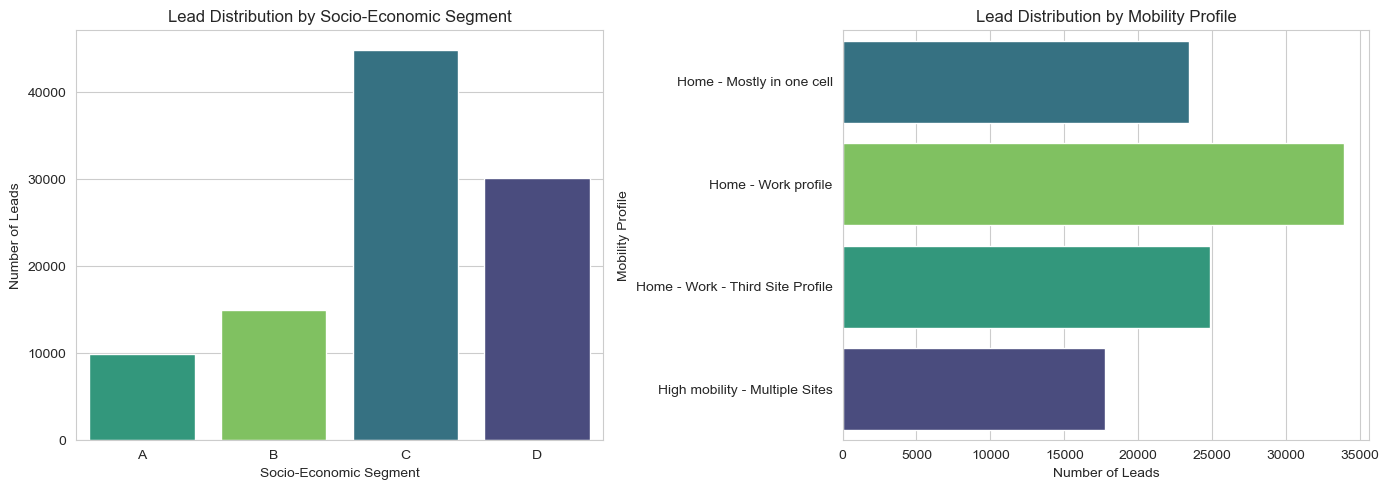

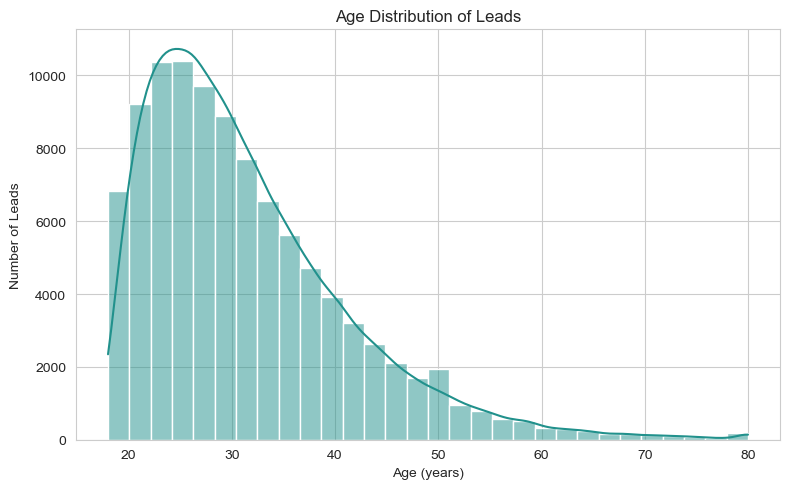

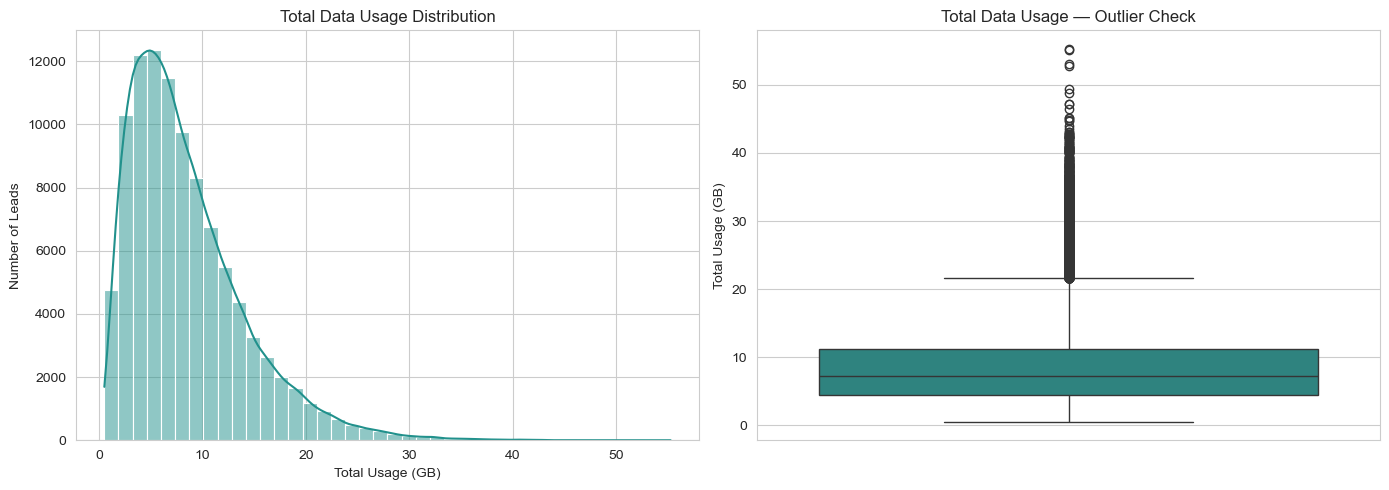

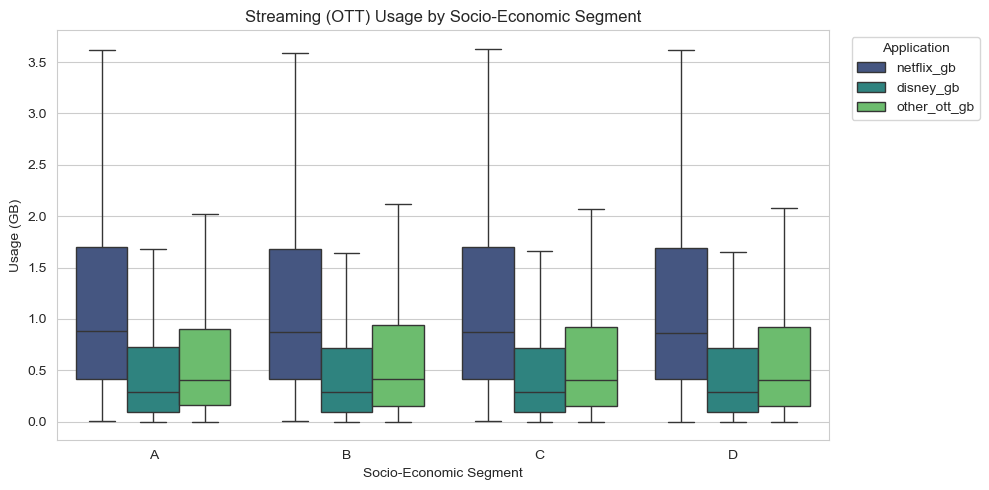

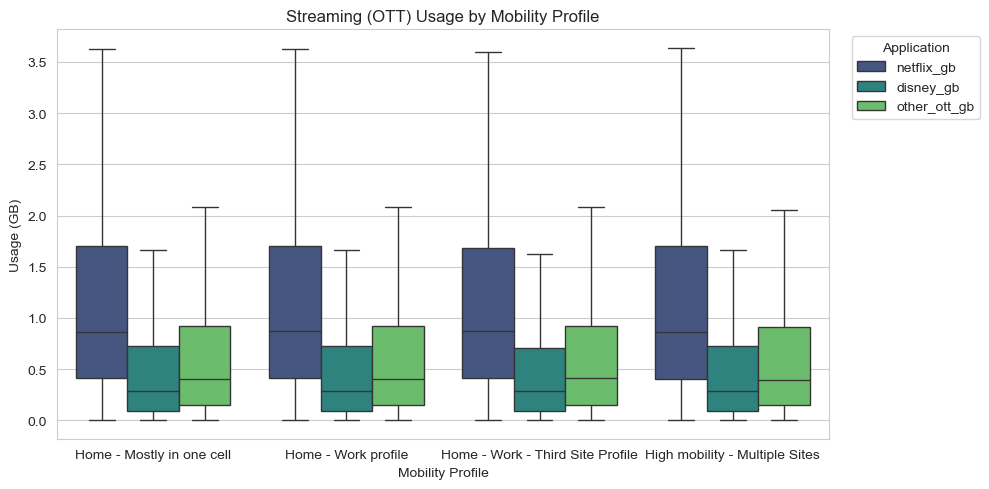

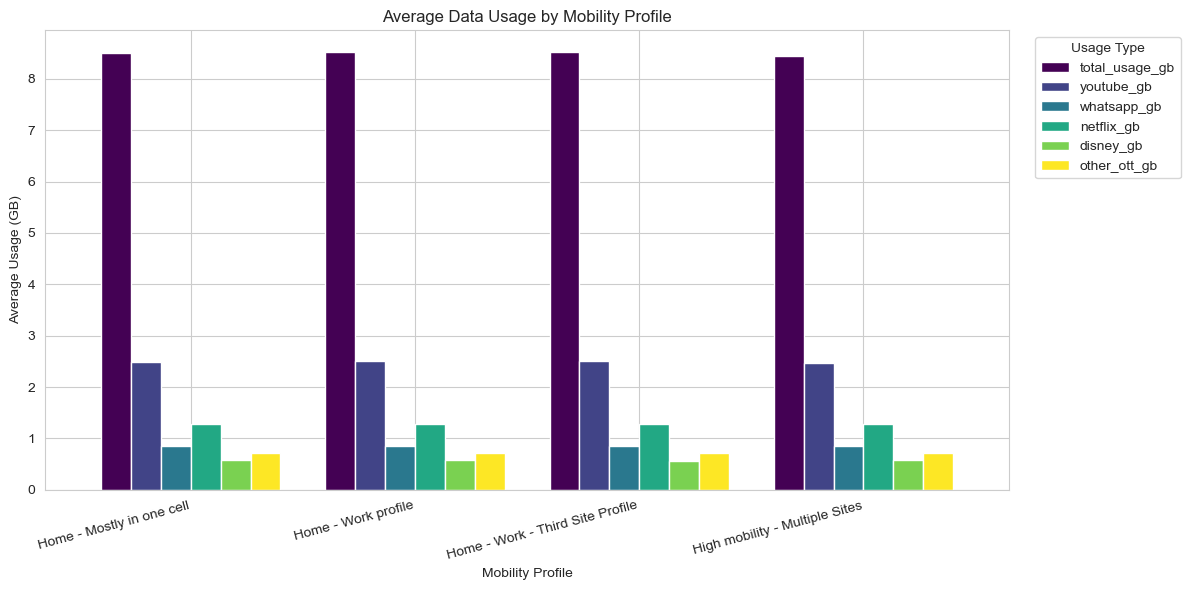

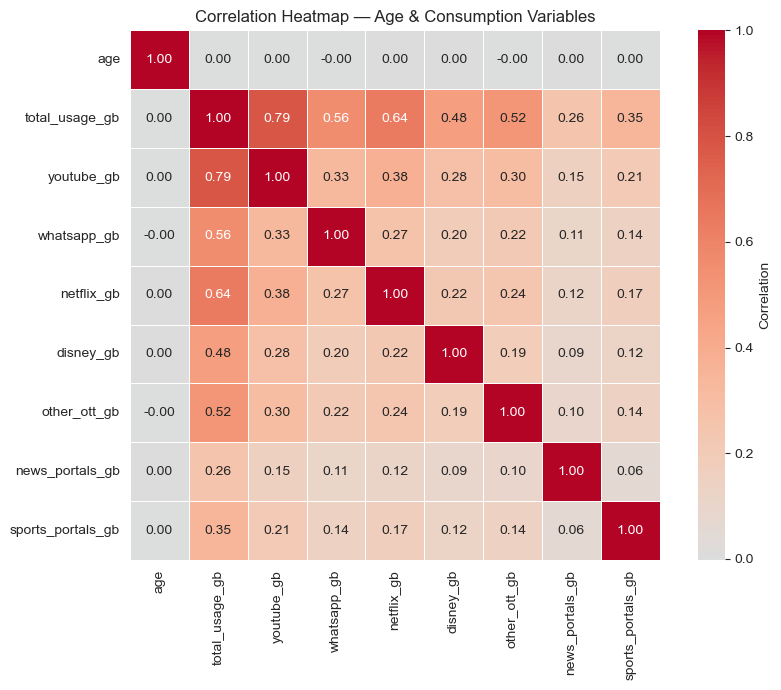

In [8]:
# ============================================================
# Descriptive Analytics: Lead Base Profiling
# ============================================================
# Goal: understand demographic and consumption patterns in the lead base
# to inform which offer components (Internet speed, TV tier, OTT bundles,
# Wall-to-Wall WiFi) resonate with which customer profiles.

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = "viridis"
plt.rcParams["figure.dpi"] = 100

# Explicit, business-meaningful ordering for categorical variables
segment_order = ["A", "B", "C", "D"]
mobility_order = [
    "Home - Mostly in one cell",
    "Home - Work profile",
    "Home - Work - Third Site Profile",
    "High mobility - Multiple Sites",
]

app_usage_cols = ["youtube_gb", "whatsapp_gb", "netflix_gb", "disney_gb", "other_ott_gb"]
ott_cols = ["netflix_gb", "disney_gb", "other_ott_gb"]
numeric_consumption_cols = ["age", "total_usage_gb"] + app_usage_cols + ["news_portals_gb", "sports_portals_gb"]

# ------------------------------------------------------------
# Section 1: Univariate Analysis — Who is our customer base?
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=lead_base, x="socio_economic_segment", order=segment_order,
    hue="socio_economic_segment", palette=PALETTE, legend=False, ax=axes[0],
)
axes[0].set_title("Lead Distribution by Socio-Economic Segment")
axes[0].set_xlabel("Socio-Economic Segment")
axes[0].set_ylabel("Number of Leads")

sns.countplot(
    data=lead_base, y="mobility_profile", order=mobility_order,
    hue="mobility_profile", palette=PALETTE, legend=False, ax=axes[1],
)
axes[1].set_title("Lead Distribution by Mobility Profile")
axes[1].set_xlabel("Number of Leads")
axes[1].set_ylabel("Mobility Profile")

plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=lead_base, x="age", bins=30, kde=True, color=sns.color_palette(PALETTE, 1)[0])
plt.title("Age Distribution of Leads")
plt.xlabel("Age (years)")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

# Total data usage: histogram + boxplot side by side (distribution shape + outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=lead_base, x="total_usage_gb", bins=40, kde=True, ax=axes[0], color=sns.color_palette(PALETTE, 1)[0])
axes[0].set_title("Total Data Usage Distribution")
axes[0].set_xlabel("Total Usage (GB)")
axes[0].set_ylabel("Number of Leads")

sns.boxplot(data=lead_base, y="total_usage_gb", ax=axes[1], color=sns.color_palette(PALETTE, 3)[1])
axes[1].set_title("Total Data Usage — Outlier Check")
axes[1].set_ylabel("Total Usage (GB)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Section 2: Multivariate Analysis — Business-driven insights
# ------------------------------------------------------------

def boxplot_by_category(data, category_col, order, value_cols, title, xlabel):
    """Plot side-by-side boxplots of `value_cols` grouped by a categorical column."""
    melted = data.melt(
        id_vars=category_col, value_vars=value_cols,
        var_name="app", value_name="usage_gb",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=melted, x=category_col, y="usage_gb", hue="app",
        order=order, palette=PALETTE, showfliers=False,
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Usage (GB)")
    plt.legend(title="Application", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Streaming (OTT) usage vs. Socio-Economic Segment
# Why: identify which segments are more likely to buy OTT bundles / Premium TV.
boxplot_by_category(
    lead_base, "socio_economic_segment", segment_order, ott_cols,
    "Streaming (OTT) Usage by Socio-Economic Segment",
    "Socio-Economic Segment",
)

# Streaming (OTT) usage vs. Mobility Profile
# Why: home-based profiles may be better OTT/Premium-TV targets than high-mobility ones.
boxplot_by_category(
    lead_base, "mobility_profile", mobility_order, ott_cols,
    "Streaming (OTT) Usage by Mobility Profile",
    "Mobility Profile",
)

# Mobility profile vs. total and app-level usage (mean comparison)
# Why: test whether high-mobility profiles (3 & 4) skew toward mobile data usage
# while home-based profiles (1 & 2) skew toward streaming — informs whether to target
# Wall-to-Wall WiFi (home-based) vs. high mobile data plans (high-mobility).
mobility_summary = (
    lead_base.groupby("mobility_profile")[["total_usage_gb"] + app_usage_cols]
    .mean()
    .reindex(mobility_order)
)

mobility_summary.plot(kind="bar", figsize=(12, 6), colormap=PALETTE, width=0.8)
plt.title("Average Data Usage by Mobility Profile")
plt.xlabel("Mobility Profile")
plt.ylabel("Average Usage (GB)")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Usage Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Correlation heatmap of numerical consumption variables
# Why: discover which applications are consumed together (e.g., YouTube & WhatsApp)
# to design custom bundles.
plt.figure(figsize=(9, 7))
corr = lead_base[numeric_consumption_cols].corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Heatmap — Age & Consumption Variables")
plt.tight_layout()
plt.show()



### **Simulation**

**Coding cell: follow the instructions**

Use Python to split the `lead_base` dataframe into `random_base` and `low_offer_base`. **Use the exact naming convention.** Assign the first 50,000 records to the random base and the second 50,000 records to the second base.

In [10]:
# First 50,000 records (from 0 to 49,999)
random_base = lead_base.iloc[:50_000].reset_index(drop=True)

# Second 50,000 records (from 50,000 to 99,999) using the exact naming convention
low_offer_base = lead_base.iloc[50_000:100_000].reset_index(drop=True)

print(f"random_base size:    {random_base.shape}")
display(random_base.head())
print(f"low_offer_base size: {low_offer_base.shape}")
display(low_offer_base.head())

# Assign low_offer_base to low_cost_base to ensure compatibility with subsequent code cells
low_cost_base = low_offer_base

random_base size:    (50000, 13)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,61741240,33,D,High mobility - Multiple Sites,Android low end,2.92,0.264,0.058,1.569,0.144,0.024,0.046,0.008
1,69909745,30,C,High mobility - Multiple Sites,iPhone mid end,5.47,1.769,1.424,1.517,0.012,0.078,0.359,0.004
2,66081977,24,A,Home - Mostly in one cell,iPhone mid end,8.02,3.538,0.219,1.297,0.195,0.923,0.000,0.240
3,62136017,26,C,Home - Work - Third Site Profile,Android high end,10.09,3.442,0.216,1.931,0.020,0.767,0.004,2.053
4,64477734,20,C,Home - Work profile,Android low end,20.75,2.845,1.899,0.111,0.074,4.708,0.545,5.782


low_offer_base size: (50000, 13)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,69579961,22,C,Home - Work - Third Site Profile,Android high end,6.71,4.065,1.076,0.214,0.126,0.250,0.154,0.009
1,61356398,38,D,High mobility - Multiple Sites,Android low end,11.44,4.269,1.965,0.944,0.857,1.727,0.068,0.026
2,67455745,25,C,Home - Mostly in one cell,Android high end,7.20,1.590,1.234,0.624,0.011,0.993,0.607,0.093
3,63800021,58,D,High mobility - Multiple Sites,Android high end,19.84,3.624,2.176,5.599,0.981,2.383,0.000,0.021
4,62910692,28,D,Home - Work profile,iPhone mid end,4.27,1.687,1.222,0.697,0.105,0.078,0.000,0.114


Assign offers using functions from the experiment library.

In [11]:
### Do not modify this cell

from data_and_supporting_code.experiments import random_offer as random_offer_fn, fixed_offer

random_offer = random_offer_fn(random_base)
low_cost_offer = fixed_offer(low_cost_base)

print(f"random_offer size:    {random_offer.shape}")
display(random_offer.head())
print(f"low_cost_offer size: {low_cost_offer.shape}")
display(low_cost_offer.head())

random_offer size:    (50000, 22)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,...,sports_portals_gb,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description
0,61741240,33,D,High mobility - Multiple Sites,Android low end,2.92,0.264,0.058,1.569,0.144,...,0.008,0,1,0,1,1,0,1,1,Low Speed Internet + Premium TV + Disney OTT +...
1,69909745,30,C,High mobility - Multiple Sites,iPhone mid end,5.47,1.769,1.424,1.517,0.012,...,0.004,0,1,1,0,1,0,1,1,Low Speed Internet + Basic TV + Disney OTT + V...
2,66081977,24,A,Home - Mostly in one cell,iPhone mid end,8.02,3.538,0.219,1.297,0.195,...,0.240,0,1,0,0,0,1,1,1,Low Speed Internet + Paramount OTT + Voice Lin...
3,62136017,26,C,Home - Work - Third Site Profile,Android high end,10.09,3.442,0.216,1.931,0.020,...,2.053,1,0,0,0,1,0,0,1,High Speed Internet + Disney OTT + Wall to Wal...
4,64477734,20,C,Home - Work profile,Android low end,20.75,2.845,1.899,0.111,0.074,...,5.782,1,0,1,0,0,1,1,0,High Speed Internet + Basic TV + Paramount OTT...


low_cost_offer size: (50000, 22)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,...,sports_portals_gb,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description
0,69579961,22,C,Home - Work - Third Site Profile,Android high end,6.71,4.065,1.076,0.214,0.126,...,0.009,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
1,61356398,38,D,High mobility - Multiple Sites,Android low end,11.44,4.269,1.965,0.944,0.857,...,0.026,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
2,67455745,25,C,Home - Mostly in one cell,Android high end,7.20,1.590,1.234,0.624,0.011,...,0.093,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
3,63800021,58,D,High mobility - Multiple Sites,Android high end,19.84,3.624,2.176,5.599,0.981,...,0.021,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
4,62910692,28,D,Home - Work profile,iPhone mid end,4.27,1.687,1.222,0.697,0.105,...,0.114,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV


In [12]:
from data_and_supporting_code.sim import sim

random_results = sim(random_offer)
low_cost_results = sim(low_cost_offer)

display(random_results.head())

print(f"Random offer converted:        {random_results['converted'].sum():,} ({random_results['converted'].sum() / len(random_results):.1%})")
print(f"Random Margin:                 {random_results['total_margin'].sum():,.2f}")
print()
print(f"Low cost offer converted:         {low_cost_results['converted'].sum():,} ({low_cost_results['converted'].sum() / len(low_cost_results):.1%})")
print(f"Los cost offer Margin:                  {low_cost_results['total_margin'].sum():,.2f}")

,phone_number,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description,offer_description,total_price,total_margin,converted
0,61741240,0,1,0,1,1,0,1,1,Low Speed Internet + Premium TV + Disney OTT +...,Low Speed Internet + Premium TV + Disney OTT +...,72,0.0,False
1,69909745,0,1,1,0,1,0,1,1,Low Speed Internet + Basic TV + Disney OTT + V...,Low Speed Internet + Basic TV + Disney OTT + V...,59,0.0,False
2,66081977,0,1,0,0,0,1,1,1,Low Speed Internet + Paramount OTT + Voice Lin...,Low Speed Internet + Paramount OTT + Voice Lin...,47,0.0,False
3,62136017,1,0,0,0,1,0,0,1,High Speed Internet + Disney OTT + Wall to Wal...,High Speed Internet + Disney OTT + Wall to Wal...,54,0.0,False
4,64477734,1,0,1,0,0,1,1,0,High Speed Internet + Basic TV + Paramount OTT...,High Speed Internet + Basic TV + Paramount OTT...,66,0.0,False


Random offer converted:        397 (0.8%)
Random Margin:                 15,241.30

Low cost offer converted:         1,352 (2.7%)
Los cost offer Margin:                  33,881.12


**Coding cell: follow the instructions**

Use Python or SQLite to run descriptive analytics on your results. Using the random offer converted results, try to model price elasticity. Provide relevant insights from both experiments to understand customer preferences.

=== Overall Conversion Rate Comparison ===
       Experiment  Conversion Rate  Avg. Total Margin ($)
0    Random Offer           0.0079                 0.3048
1  Low-Cost Offer           0.0270                 0.6776

=== Top Bundles by Conversion Rate: Random Offer ===
                                                    customers  \
offer_description                                               
High Speed Internet + Premium TV + Disney OTT +...        567   
High Speed Internet + Wall to Wall Wifi                   506   
Low Speed Internet                                        511   
High Speed Internet + Premium TV + Disney OTT +...        491   
High Speed Internet + Premium TV + Paramount OT...        507   
High Speed Internet + Paramount OTT + Wall to W...        509   
High Speed Internet + Disney OTT + Wall to Wall...        521   
High Speed Internet + Premium TV + Wall to Wall...        550   
High Speed Internet + Premium TV + Disney OTT             500   
High Speed Int

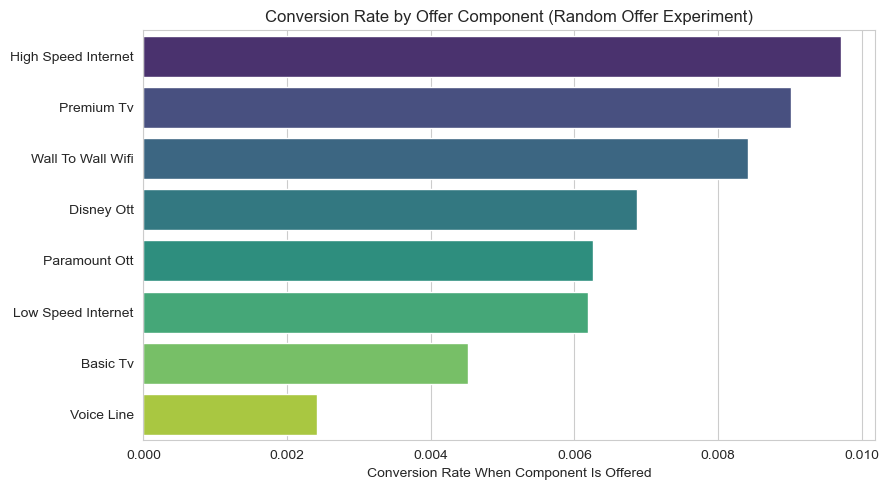


=== Price Elasticity Model: Logit(converted) ~ total_price + product mix ===
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49992
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                 0.06562
Time:                        10:22:01   Log-Likelihood:                -2163.3
converged:                       True   LL-Null:                       -2315.2
Covariance Type:            nonrobust   LLR p-value:                 9.039e-62
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -4.7614      0.748     -6.365      0.000      -6.228      -3.295
total_pr

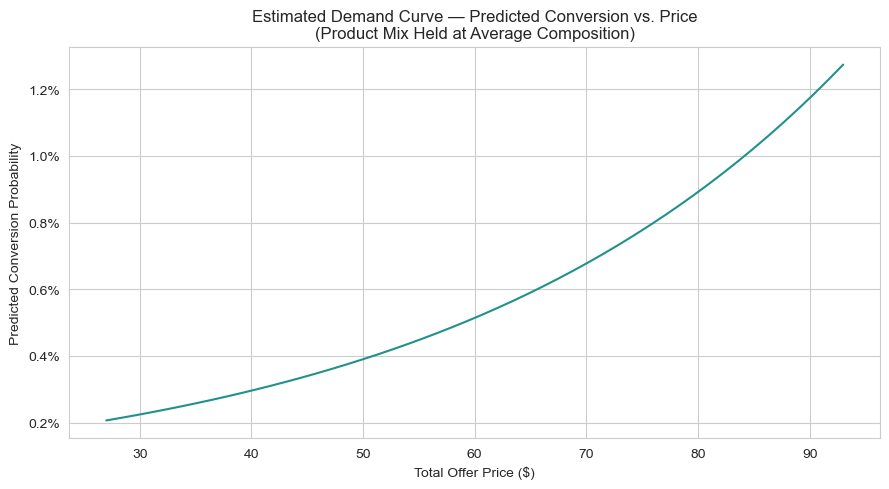


=== Interpreting the Price Coefficient ===
- Coefficient sign: positive (0.0277 log-odds per $1) — higher price increases the odds of conversion, holding product mix fixed, consistent with standard demand theory.
- Odds ratio 1.0281: each extra $1 charged multiplies the odds of conversion by 1.0281 (-2.81% relative change in odds per dollar).

=== Conversion Shift: Random Baseline -> Low-Cost Strategy ===
- Random offer:   avg. price $59.47 -> conversion rate 0.79%
- Low-cost offer: avg. price $37.00 -> conversion rate 2.70%
- Lowering price by $22.47 on average shifted conversion by 1.91 percentage points (3.41x baseline), directionally consistent with the negative price coefficient estimated above — though the low-cost offer also strips out add-ons (Premium TV, OTT bundles, Voice, WiFi), so part of this shift reflects a simpler, less confusing product mix in addition to the pure price effect.


In [19]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick

sns.set_style("whitegrid")
PALETTE = "viridis"

random_results = random_results.loc[:, ~random_results.columns.duplicated()]
low_cost_results = low_cost_results.loc[:, ~low_cost_results.columns.duplicated()]


# ============================================================
# Section 1: Comparative Descriptive Analytics
# ============================================================

offer_feature_cols = [
    "offer_high_speed_internet", "offer_low_speed_internet", "offer_basic_tv",
    "offer_premium_tv", "offer_disney_ott", "offer_paramount_ott",
    "offer_voice_line", "offer_wall_to_wall_wifi",
]

# 1a. Overall conversion rate: random (varied offers) vs. low-cost (fixed offer)
conversion_comparison = pd.DataFrame({
    "Experiment": ["Random Offer", "Low-Cost Offer"],
    "Conversion Rate": [random_results["converted"].mean(), low_cost_results["converted"].mean()],
    "Avg. Total Margin ($)": [random_results["total_margin"].mean(), low_cost_results["total_margin"].mean()],
})
print("=== Overall Conversion Rate Comparison ===")
print(conversion_comparison.round(4))


def bundle_performance(results_df, top_n=10):
    """Conversion rate and average margin per unique offer bundle."""
    return (
        results_df.groupby("offer_description")
        .agg(
            customers=("converted", "size"),
            conversion_rate=("converted", "mean"),
            avg_margin_per_customer=("total_margin", "mean"),
        )
        .sort_values("conversion_rate", ascending=False)
        .head(top_n)
    )

print("\n=== Top Bundles by Conversion Rate: Random Offer ===")
print(bundle_performance(random_results).round(4))

print("\n=== Top Bundles by Conversion Rate: Low-Cost Offer ===")
# Note: fixed_offer() always assigns the same single bundle, so this experiment
# yields exactly one row — included for structural symmetry with the random case.
print(bundle_performance(low_cost_results).round(4))

# 1c. Individual component conversion rate: acceptance rate when a feature IS offered
# (meaningful only in the random experiment, since the low-cost experiment never
# varies these components)
component_conversion = pd.DataFrame({
    "Offer Component": [c.replace("offer_", "").replace("_", " ").title() for c in offer_feature_cols],
    "Conversion Rate When Offered": [
        random_results.loc[random_results[c] == 1, "converted"].mean() for c in offer_feature_cols
    ],
}).sort_values("Conversion Rate When Offered", ascending=False)
print("\n=== Conversion Rate by Individual Offer Component (Random Offer) ===")
print(component_conversion.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=component_conversion, x="Conversion Rate When Offered", y="Offer Component",
    hue="Offer Component", palette=PALETTE, legend=False,
)
plt.title("Conversion Rate by Offer Component (Random Offer Experiment)")
plt.xlabel("Conversion Rate When Component Is Offered")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ============================================================
# Section 2: Price Elasticity Modeling (Random Offer Experiment)
# ============================================================


model_flags = [
    "offer_high_speed_internet", "offer_basic_tv", "offer_premium_tv",
    "offer_disney_ott", "offer_paramount_ott", "offer_voice_line",
]

X = sm.add_constant(random_results[["total_price"] + model_flags])
y = random_results["converted"].astype(int)

assert np.linalg.matrix_rank(X.values) == X.shape[1], "Design matrix is rank-deficient"

price_mix_model = sm.Logit(y, X).fit(disp=False)
print("\n=== Price Elasticity Model: Logit(converted) ~ total_price + product mix ===")
print(price_mix_model.summary())

price_coef = price_mix_model.params["total_price"]
print(f"\nHolding product mix fixed, each additional $1 in price changes the "
      f"log-odds of conversion by {price_coef:.4f} (odds ratio: {np.exp(price_coef):.4f}).")
if price_mix_model.pvalues["total_price"] > 0.05:
    print("Note: this effect is not statistically significant at the 5% level in "
          "this run — expected, since once product mix is held fixed, the only "
          "remaining price variation comes from the $4 Wall-to-Wall WiFi add-on, "
          "a narrow range that limits the power to detect a pure price effect.")

# 2b. Estimated demand curve: predicted conversion probability across price tiers,
# holding the product mix fixed at its average observed composition
price_grid = np.linspace(random_results["total_price"].min(), random_results["total_price"].max(), 50)
avg_mix = random_results[model_flags].mean()

X_grid = pd.DataFrame({"total_price": price_grid})
for flag in model_flags:
    X_grid[flag] = avg_mix[flag]
X_grid.insert(0, "const", 1.0)
X_grid = X_grid[X.columns]  # match fitted model's column order exactly

predicted_curve = pd.DataFrame({
    "total_price": price_grid,
    "predicted_conversion_rate": price_mix_model.predict(X_grid),  # kept as raw 0-1 probability
})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=predicted_curve, x="total_price", y="predicted_conversion_rate",
    color=sns.color_palette(PALETTE, 1)[0],
)
plt.title("Estimated Demand Curve — Predicted Conversion vs. Price\n(Product Mix Held at Average Composition)")
plt.xlabel("Total Offer Price ($)")
plt.ylabel("Predicted Conversion Probability")
# Display the y-axis as a percentage without rescaling the underlying 0-1 values
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()

# ============================================================
# Section 3: Experiment Insights — Random Baseline vs. Low-Cost Strategy
# ============================================================

random_conv = random_results["converted"].mean()
low_cost_conv = low_cost_results["converted"].mean()
random_price = random_results["total_price"].mean()
low_cost_price = low_cost_results["total_price"].mean()

print("\n=== Interpreting the Price Coefficient ===")
print(f"- Coefficient sign: {'negative' if price_coef < 0 else 'positive'} "
      f"({price_coef:.4f} log-odds per $1) — higher price "
      f"{'reduces' if price_coef < 0 else 'increases'} the odds of conversion, "
      "holding product mix fixed, consistent with standard demand theory.")
print(f"- Odds ratio {np.exp(price_coef):.4f}: each extra $1 charged multiplies the odds "
      f"of conversion by {np.exp(price_coef):.4f} "
      f"({(1 - np.exp(price_coef)) * 100:.2f}% relative change in odds per dollar).")

print("\n=== Conversion Shift: Random Baseline -> Low-Cost Strategy ===")
print(f"- Random offer:   avg. price ${random_price:.2f} -> conversion rate {random_conv:.2%}")
print(f"- Low-cost offer: avg. price ${low_cost_price:.2f} -> conversion rate {low_cost_conv:.2%}")
print(f"- Lowering price by ${random_price - low_cost_price:.2f} on average shifted conversion by "
      f"{(low_cost_conv - random_conv) * 100:.2f} percentage points "
      f"({low_cost_conv / random_conv:.2f}x baseline), directionally consistent with the negative "
      "price coefficient estimated above — though the low-cost offer also strips out add-ons "
      "(Premium TV, OTT bundles, Voice, WiFi), so part of this shift reflects a simpler, "
      "less confusing product mix in addition to the pure price effect.")





## Building your recommender model

In [20]:
### Do not modify this cell

for i in range(1, 11):
    globals()[f"train_leads_optimized_{i}"] = generate_lead_base(n=50_000)

#This loop created ten train datasets (train_leads_optimized_1, train_leads_optimized_2,train_leads_optimized_3... train_leads_optimized_10)
display(train_leads_optimized_1.head())

test_leads_optimized = generate_lead_base(n=50_000)

,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,68031392,24,B,Home - Work profile,iPhone mid end,12.18,5.530,1.662,1.466,1.027,0.756,0.000,0.923
1,61682272,38,A,Home - Work - Third Site Profile,iPhone high end,10.57,3.613,1.494,2.625,0.075,0.021,0.036,1.597
2,65150853,31,C,Home - Mostly in one cell,iPhone mid end,3.48,0.931,0.153,0.750,0.398,0.061,0.024,0.001
3,64907760,21,C,Home - Work - Third Site Profile,Android high end,13.43,1.816,0.861,1.140,0.037,1.364,0.006,0.543
4,63031299,39,D,Home - Mostly in one cell,Android low end,14.72,1.989,6.585,1.312,0.824,2.115,0.000,0.489


You will now build a recommender model that optimizes the offer presented to each customer. Use the `leads_optimized` base from the cell above to test your offer strategy. 

### Important constraint:

You can only use the 500.000 leads created for the 10 batches of leads for training `train_leads_optimized_1` to `train_leads_optimized_10`. This resembles 10 biweekly campaign runs. Your solution shall be tested then with the `test_leads_optimized` to compare results against the random assignment and the low_cost assignment.

### How to run the sim function:

Offer results can be obtained with the `sim` function as follows:

*optimized_results = sim(optimized_offer)*

Your `optimized_offer` dataframe must include the following columns to run the simulation:

- **Columns from the original base** (no transformation needed — **please do not make any changes to the originally created columns**): `phone_number`, `age`, `socio_economic_segment`, `mobility_profile`, `device`, `total_usage_gb`, `youtube_gb`, `whatsapp_gb`, `netflix_gb`, `disney_gb`, `other_ott_gb`, `news_portals_gb`, `sports_portals_gb`
- **Offer columns** — one-hot encoding for each offer feature (1 or 0): `offer_high_speed_internet`, `offer_low_speed_internet`, `offer_basic_tv`, `offer_premium_tv`, `offer_disney_ott`, `offer_paramount_ott`, `offer_voice_line`, `offer_wall_to_wall_wifi`

**Important: If your dataframe does not include any of these columns, the `sim` function will fail. It will also fail if a customer does not have an Internet offer assigned or if both TV options are simultaneously offered**

The `sim` function will run the campaign and return results that can be compared with the random and low-cost strategies.

### Critical Warning

This case has been tested with several AI solutions. AI support is permitted (and encouraged), but the candidate must fully understand, explain, and be able to modify any code provided.

The function `sim()` must be treated as a **black-box stochastic environment**. Its internal logic is unknown and must not be reverse-engineered or inferred.

Any solution will be **disqualified** if it relies on:

* Reverse engineering or deterministic assignment based on `sim()`
* Exhaustive or near-exhaustive evaluation of all offer combinations
  (real campaigns are costly and slow, so brute-force approaches are not feasible)

Candidates should build a **learning-based recommendation policy** (e.g., reinforcement learning, contextual bandits, or similar) that:

* Learns from **limited interactions** with `sim()`
* Balances **exploration and exploitation**
* Generalizes to unseen customers (not a lookup table)

Submissions will be evaluated on methodology, sample efficiency, generalization, and clarity.





## Validate your final result and report final KPIs

In [ ]:
#Do not modify this cell
import pandas as pd
final_test_validation_base = pd.read_parquet("data_and_supporting_code/final_test_validation_base.parquet")
display(final_test_validation_base.head())

random_offer_test = random_offer_fn(final_test_validation_base)
random_result_test = sim(random_offer_test)
low_cost_offer_test = fixed_offer(final_test_validation_base)
low_cost_result_test = sim(low_cost_offer_test)

In [ ]:
#Write your code here, do not change the name of the offer test dataframe

optimized_offer_test   = your_optimized_function(final_test_validation_base)

In [ ]:
#Do not modify this cell
optimized_result_test = sim(optimized_offer_test)
# ── Benchmark comparison ──────────────────────────────────────────────────────
rows = []
for name, df in [
    ('Random Offer (baseline)',   random_result_test),
    ('Low-Cost Offer (baseline)', low_cost_result_test),
    ('Contextual Bandit (ours)',  optimized_result_test),
]:
    conv_df = df[df['converted']]
    rows.append({
        'Strategy':           name,
        'Customers':          f"{len(df):,}",
        'Converted':          f"{df['converted'].sum():,}",
        'Conv. Rate':         f"{df['converted'].mean():.1%}",
        'Total Margin':       f"${df['total_margin'].sum():,.0f}",
        'Margin / Convert':   f"${conv_df['total_margin'].mean():.2f}" if len(conv_df) else '—',
        'Margin / Customer':  f"${df['total_margin'].mean():.2f}",
    })
print("=== Strategy Comparison ===")
display(pd.DataFrame(rows))

# ── Offer-mix comparison ──────────────────────────────────────────────────────
offer_feature_cols = [c for c in optimized_offer_test.columns
                      if c.startswith('offer_') and c != 'offer_description']
mix = pd.DataFrame({
    'Optimized':   optimized_offer_test[offer_feature_cols].mean(),
    'Low-Cost': low_cost_offer_test[offer_feature_cols].mean(),
    'Random':   random_offer_test[offer_feature_cols].mean(),
})
fig, ax = plt.subplots(figsize=(12, 4))
mix.T.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Offer Component Incidence: Strategy Comparison')
ax.set_ylabel('Fraction of Customers Offered (0–1)')
ax.set_xticklabels(['Bandit', 'Low-Cost', 'Random'], rotation=0)
ax.legend(
    [c.replace('offer_', '').replace('_', ' ').title() for c in offer_feature_cols],
    loc='upper right', fontsize=8, ncol=2,
)
plt.tight_layout()
plt.show()

# ── Lift summary ──────────────────────────────────────────────────────────────
opt_m = optimized_result_test['total_margin'].sum()
lc_m  = low_cost_result_test['total_margin'].sum()
rnd_m = random_result_test['total_margin'].sum()
print(f"Lift vs Random Offer:   {opt_m/rnd_m:.2f}× (+${opt_m - rnd_m:,.0f})")
print(f"Lift vs Low-Cost Offer: {opt_m/lc_m:.2f}× (+${opt_m - lc_m:,.0f})")